# ***Supervised Models***

In [ ]:
# Library
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# conect drive file
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Data Preprocessing**

In [ ]:
path = '/content/drive/MyDrive/adult.csv'
adult = pd.read_csv(path)
adult

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [ ]:
# Find Missing Values ... (result: there is no missing values)
adult.isnull().sum()
# Handle missing values

,0
age,0
workclass,0
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,0
relationship,0
race,0
gender,0


In [ ]:
# label encoding for (income); convert  <=50K to 1 & >50K to 0
adult['income'] = adult['income'].map({'<=50K': 0, '>50K': 1})
adult

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,0
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,1
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,0
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,0


In [ ]:
# Encode (one-hot encode) the categorical columns
# All categorical columns for encoding

categorical_col = ['workclass', 'education', 'marital-status', 'occupation','relationship', 'race', 'gender', 'native-country']

# Apply one-hot encoding
adult_encoded = pd.get_dummies(adult, columns=categorical_col, dtype=int)

# Display the result
display(adult_encoded.head())

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week,income,workclass_?,workclass_Federal-gov,workclass_Local-gov,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,25,226802,7,0,0,40,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,38,89814,9,0,0,50,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,28,336951,12,0,0,40,1,0,0,1,...,0,0,0,0,0,0,0,1,0,0
3,44,160323,10,7688,0,40,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,18,103497,10,0,0,30,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0


In [ ]:
#Separate features (X) and target (y)
X_adult = adult_encoded.drop('income', axis=1)
y_adult = adult_encoded['income']

In [ ]:
# (( Split the data into training and testing sets "70% train, 30% test" ))
X_adult_test, X_adult_train, y_adult_test, y_adult_train = train_test_split(X_adult, y_adult, test_size=0.3, random_state=42)

In [ ]:
# Standardize
scaler = StandardScaler()
# just select numerical column
num_of_col = ['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
X_adult_train_scaled = scaler.fit_transform(X_adult_train[num_of_col])
X_adult_test_scaled = scaler.transform(X_adult_test[num_of_col])

# **Model Building & Evaluation then Visualization**

*Logistic Regression model*

In [ ]:
# Logistic Regression model
LR_model = LogisticRegression(max_iter=2500)

# Train the model
LR_model.fit(X_adult_train_scaled, y_adult_train)

LogisticRegression(max_iter=2500)

In [ ]:
# Making predictions on the test set
y_adult_pred_LR = LR_model.predict(X_adult_test_scaled)

# ((predictions)) vs (actual values)
print("Predicted values:", y_adult_pred_LR)
print()
print("Actual values:", y_adult_test.values)

Predicted values: [0 0 0 ... 0 0 0]

Actual values: [0 0 0 ... 0 0 1]


In [ ]:
# Compute metrics Logistic Regression on Adult dataset
LR_accuracy_adult = accuracy_score(y_adult_test, y_adult_pred_LR) # accuracy

LR_precision_adult = precision_score(y_adult_test, y_adult_pred_LR) # precision

LR_recall_adult = recall_score(y_adult_test, y_adult_pred_LR) # recall

LR_f1_adult = f1_score(y_adult_test, y_adult_pred_LR) # f1

LR_roc_auc_adult = roc_auc_score(y_adult_test, LR_model.predict_proba(X_adult_test_scaled)[:, 1]) # ROC-AUC Score

print("Logistic Regression Evaluation on Adult Data:")
print(f"Accuracy: {LR_accuracy_adult:.4f}")
print(f"Precision: {LR_precision_adult:.4f}")
print(f"Recall: {LR_recall_adult:.4f}")
print(f"F1-Score: {LR_f1_adult:.4f}")
print(f"ROC-AUC Score: {LR_roc_auc_adult:.4f}")

Logistic Regression Evaluation on Adult Data:
Accuracy: 0.8128
Precision: 0.7117
Recall: 0.3795
F1-Score: 0.4950
ROC-AUC Score: 0.8291


/nconfusion matrices for Logistic Regression


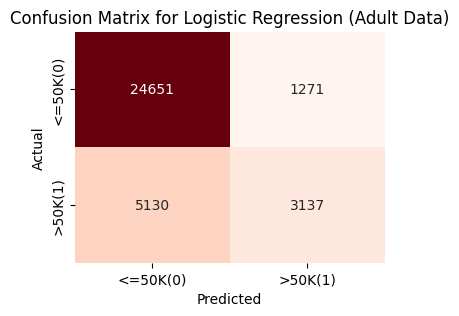

In [ ]:
# confusion matrices for Logistic Regression
LR_cm_adult = confusion_matrix(y_adult_test, y_adult_pred_LR)
print("/nconfusion matrices for Logistic Regression")
plt.figure(figsize=(4, 3))
sns.heatmap(LR_cm_adult, annot=True, fmt='d', cmap='Reds', cbar=False, xticklabels=['<=50K(0)', '>50K(1)'], yticklabels=['<=50K(0)', '>50K(1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Logistic Regression (Adult Data)')
plt.show()

*Naive Bayes model*

In [ ]:
# Naive Bayes model
nb_model = GaussianNB()

# Train the model
nb_model.fit(X_adult_train_scaled, y_adult_train)

GaussianNB()

In [ ]:
# Making predictions on the test set
y_adult_pred_nb = nb_model.predict(X_adult_test_scaled)

# ((predictions)) vs (actual values)
print("Predicted values:", y_adult_pred_nb)
print()
print("Actual values:", y_adult_test.values)

Predicted values: [0 0 0 ... 0 0 0]

Actual values: [0 0 0 ... 0 0 1]


In [ ]:
# Compute metrics NB on Adult dataset
nb_accuracy = accuracy_score(y_adult_test, y_adult_pred_nb) # accuracy

nb_precision = precision_score(y_adult_test, y_adult_pred_nb) # precision

nb_recall = recall_score(y_adult_test, y_adult_pred_nb) # recall

nb_f1 = f1_score(y_adult_test, y_adult_pred_nb) # f1

nb_roc_auc = roc_auc_score(y_adult_test, nb_model.predict_proba(X_adult_test_scaled)[:, 1]) # ROC-AUC Score

print("\nNaive Bayes Evaluation on Adult Data:")
print(f"Accuracy: {nb_accuracy:.4f}")
print(f"Precision: {nb_precision:.4f}")
print(f"Recall: {nb_recall:.4f}")
print(f"F1-Score: {nb_f1:.4f}")
print(f"ROC-AUC Score: {nb_roc_auc:.4f}")


Naive Bayes Evaluation on Adult Data:
Accuracy: 0.7947
Precision: 0.6663
Recall: 0.3022
F1-Score: 0.4158
ROC-AUC Score: 0.8288


/nconfusion matrices for Naive Bayes


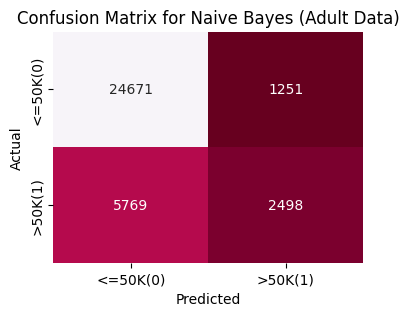

In [ ]:
# confusion matrices for # Naive Bayes
nb_cm_adult = confusion_matrix(y_adult_test, y_adult_pred_nb)
print("/nconfusion matrices for Naive Bayes")
plt
plt.figure(figsize=(4, 3))
sns.heatmap(nb_cm_adult, annot=True, fmt='d', cmap='PuRd_r', cbar=False, xticklabels=['<=50K(0)', '>50K(1)'], yticklabels=['<=50K(0)', '>50K(1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Naive Bayes (Adult Data)')
plt.show()

*BernoulliNB*

In [ ]:
# BernoulliNB
b_model = BernoulliNB()

# Train the model
b_model.fit(X_adult_train_scaled, y_adult_train)

BernoulliNB()

In [ ]:
# # Making predictions on the test set
y_adult_pred_b = b_model.predict(X_adult_test_scaled)

# ((predictions)) vs (actual values)
print("Predicted values:", y_adult_pred_b)
print()
print("Actual values:", y_adult_test.values)

Predicted values: [0 0 0 ... 0 0 0]

Actual values: [0 0 0 ... 0 0 1]


In [ ]:
# Compute metrics BernoulliNB on Adult dataset
b_accuracy = accuracy_score(y_adult_test, y_adult_pred_b) # accuracy

b_precision = precision_score(y_adult_test, y_adult_pred_b) # precision

b_recall = recall_score(y_adult_test, y_adult_pred_b) # recall

b_f1 = f1_score(y_adult_test, y_adult_pred_b) # f1

b_roc_auc = roc_auc_score(y_adult_test, b_model.predict_proba(X_adult_test_scaled)[:, 1]) # ROC-AUC Score

print("\nBernoulli Naive Bayes Evaluation on Adult Data:")
print(f"Accuracy: {b_accuracy:.4f}")
print(f"Precision: {b_precision:.4f}")
print(f"Recall: {b_recall:.4f}")
print(f"F1-Score: {b_f1:.4f}")
print(f"ROC-AUC Score: {b_roc_auc:.4f}")


Bernoulli Naive Bayes Evaluation on Adult Data:
Accuracy: 0.8008
Precision: 0.6572
Recall: 0.3678
F1-Score: 0.4717
ROC-AUC Score: 0.7931


/nconfusion matrices for BernoulliNB


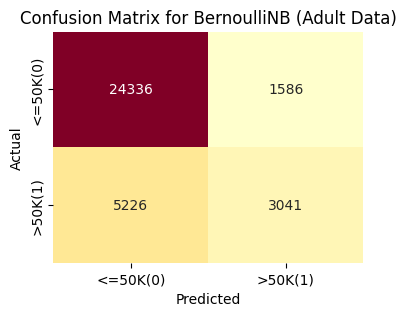

In [ ]:
# confusion matrices for BernoulliNB
b_cm_adult = confusion_matrix(y_adult_test, y_adult_pred_b)
print("/nconfusion matrices for BernoulliNB")
plt.figure(figsize=(4, 3))
sns.heatmap(b_cm_adult, annot=True, fmt='d', cmap='YlOrRd', cbar=False, xticklabels=['<=50K(0)', '>50K(1)'], yticklabels=['<=50K(0)', '>50K(1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for BernoulliNB (Adult Data)')
plt.show()

In [ ]:
# Get the predicted probabilities for the positive class for each model
# X_adult_test_scaled_full = scaler.transform(X_adult_test)

y_prob_LR = LR_model.predict_proba(X_adult_test_scaled)[:, 1]
y_prob_nb = nb_model.predict_proba(X_adult_test_scaled)[:, 1]
#y_prob_b = b_model.predict_proba(X_adult_test_scaled)[:, 1]

# Calculate the False Positive Rate, True Positive Rate, and thresholds
fpr_log, tpr_log, _ = roc_curve(y_adult_test, y_prob_LR)
fpr_gnb, tpr_gnb, _ = roc_curve(y_adult_test, y_prob_nb)
#fpr_bnb, tpr_bnb, _ = roc_curve(y_adult_test, y_prob_b)

# Calculate the Area Under the ROC Curve (AUC)
auc_log = roc_auc_score(y_adult_test, y_prob_LR)
auc_gnb = roc_auc_score(y_adult_test, y_prob_nb)
#auc_bnb = roc_auc_score(y_adult_test, y_prob_b)

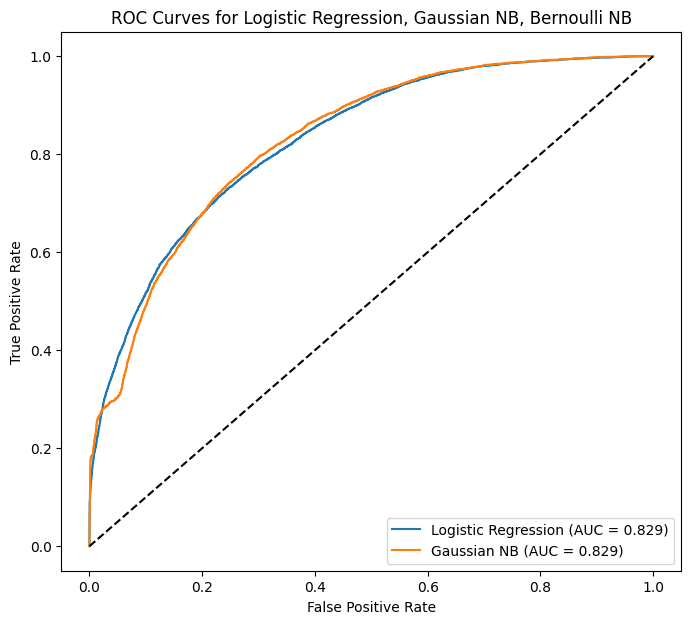

In [ ]:
# plot the carve
plt.figure(figsize=(8, 7))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {auc_log:.3f})")
plt.plot(fpr_gnb, tpr_gnb, label=f"Gaussian NB (AUC = {auc_gnb:.3f})")
#plt.plot(fpr_bnb, tpr_bnb, label=f"Bernoulli NB (AUC = {auc_bnb:.3f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Logistic Regression, Gaussian NB, Bernoulli NB")
plt.legend(loc="lower right")
plt.show()

# **Model Building & Evaluation then Visualization**

*Logistic Regression model*

In [ ]:
# Logistic Regression model
LR_model = LogisticRegression(max_iter=2500)

# Train the model
LR_model.fit(X_bcwd_train_scaled, y_bcwd_train)

LogisticRegression(max_iter=2500)

In [ ]:
# # Making predictions on the test set
y_pred = LR_model.predict(X_bcwd_test_scaled)

# ((predictions)) vs (actual values)
print("Predicted values:", y_pred)
print()
print("Actual values:", y_bcwd_test.values)

Predicted values: [0 1 1 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0 1 1 0 0 0 1 1 0 0 1 1 0 1
 0 0 0 1 0 0 1 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 0 0 1 0 0 1
 0 1 1 1 1 0 0 0 1 0 0 0 1 0 1 1 0 0 1 1 1 0 0 0 1 0 0 0 1 0 1 0 0 1 0 1 1
 1 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0]

Actual values: [0 1 1 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0 1 1 0 0 0 1 1 0 0 1 1 0 1
 0 0 0 1 0 0 1 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 0 0 1 0 0 1
 0 0 1 0 1 0 0 0 1 0 0 0 1 0 1 1 0 0 1 1 1 0 0 0 1 0 0 0 1 0 1 0 0 1 0 1 1
 1 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0]


In [ ]:
# Compute metrics Logistic Regression on BCWD dataset
LR_accuracy = accuracy_score(y_bcwd_test, y_pred) # accuracy

LR_precision = precision_score(y_bcwd_test, y_pred) # precision

LR_recall = recall_score(y_bcwd_test, y_pred) # recall

LR_f1 = f1_score(y_bcwd_test, y_pred) # f1

LR_roc_auc = roc_auc_score(y_bcwd_test, LR_model.predict_proba(X_bcwd_test_scaled)[:, 1]) # ROC-AUC Score

print("Logistic Regression Evaluation on BCWD Data:")
print(f"Accuracy: {LR_accuracy:.4f}")
print(f"Precision: {LR_precision:.4f}")
print(f"Recall: {LR_recall:.4f}")
print(f"F1-Score: {LR_f1:.4f}")
print(f"ROC-AUC Score: {LR_roc_auc:.4f}")

Logistic Regression Evaluation on BCWD Data:
Accuracy: 0.9825
Precision: 0.9688
Recall: 0.9841
F1-Score: 0.9764
ROC-AUC Score: 0.9979


/nconfusion matrices for Logistic Regression


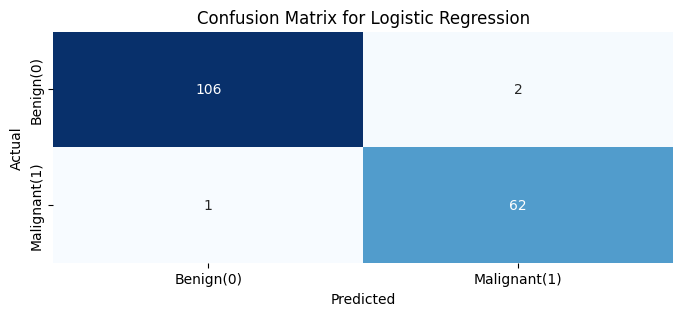

In [ ]:
# confusion matrices for Logistic Regression
LR_cm = confusion_matrix(y_bcwd_test, y_pred)
print("/nconfusion matrices for Logistic Regression")
plt.figure(figsize=(8, 3))
sns.heatmap(LR_cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Benign(0)', 'Malignant(1)'], yticklabels=['Benign(0)', 'Malignant(1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

*Naive Bayes model*

In [ ]:
# Train a Naive Bayes model ((Gaussian))
nb_model = GaussianNB()
# Train
nb_model.fit(X_bcwd_train_scaled, y_bcwd_train)

GaussianNB()

In [ ]:
# # Making predictions on the test set
b_y_pred = nb_model.predict(X_bcwd_test_scaled)

# ((predictions)) vs (actual values)
print("Predicted values:", y_pred)
print()
print("Actual values:", y_bcwd_test.values)

Predicted values: [0 1 1 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0 1 1 0 0 0 1 1 0 0 1 1 0 1
 0 0 0 1 0 0 1 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 0 0 1 0 0 1
 0 1 1 1 1 0 0 0 1 0 0 0 1 0 1 1 0 0 1 1 1 0 0 0 1 0 0 0 1 0 1 0 0 1 0 1 1
 1 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0]

Actual values: [0 1 1 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0 1 1 0 0 0 1 1 0 0 1 1 0 1
 0 0 0 1 0 0 1 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 0 0 1 0 0 1
 0 0 1 0 1 0 0 0 1 0 0 0 1 0 1 1 0 0 1 1 1 0 0 0 1 0 0 0 1 0 1 0 0 1 0 1 1
 1 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0]


In [ ]:
# Compute metrics Naive Bayes on BCWD dataset
nb_y_pred = nb_model.predict(X_bcwd_test_scaled)

nb_accuracy = accuracy_score(y_bcwd_test, nb_y_pred) # accuracy

nb_precision = precision_score(y_bcwd_test, nb_y_pred) # precision

nb_recall = recall_score(y_bcwd_test, nb_y_pred) # recall

nb_f1 = f1_score(y_bcwd_test, nb_y_pred) # f1

nb_roc_auc = roc_auc_score(y_bcwd_test, nb_model.predict_proba(X_bcwd_test_scaled)[:, 1]) # ROC-AUC Score

print("\nNaive Bayes Evaluation on BCWD Data:")
print(f"Accuracy: {nb_accuracy:.4f}")
print(f"Precision: {nb_precision:.4f}")
print(f"Recall: {nb_recall:.4f}")
print(f"F1-Score: {nb_f1:.4f}")
print(f"ROC-AUC Score: {nb_roc_auc:.4f}")


Naive Bayes Evaluation on BCWD Data:
Accuracy: 0.9357
Precision: 0.9194
Recall: 0.9048
F1-Score: 0.9120
ROC-AUC Score: 0.9927


/nconfusion matrices for Naive Bayes


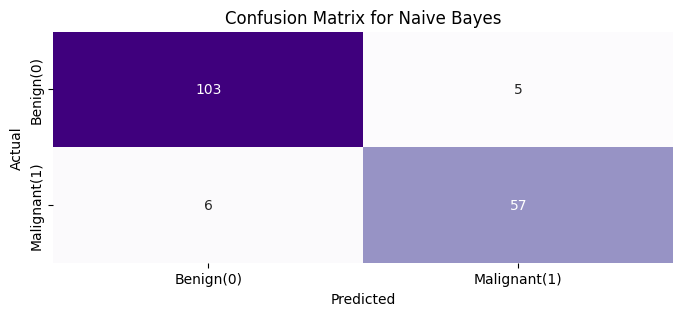

In [ ]:
# confusion matrices for Naive Bayes
nb_cm = confusion_matrix(y_bcwd_test, nb_y_pred)
print("/nconfusion matrices for Naive Bayes")
plt.figure(figsize=(8, 3))
sns.heatmap(nb_cm, annot=True, fmt='d', cmap='Purples', cbar=False, xticklabels=['Benign(0)', 'Malignant(1)'], yticklabels=['Benign(0)', 'Malignant(1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Naive Bayes')
plt.show()

Bernouli

In [ ]:
# Bernoulli Naive Bayes
b_model = BernoulliNB()
b_model.fit(X_bcwd_train_scaled, y_bcwd_train)

BernoulliNB()

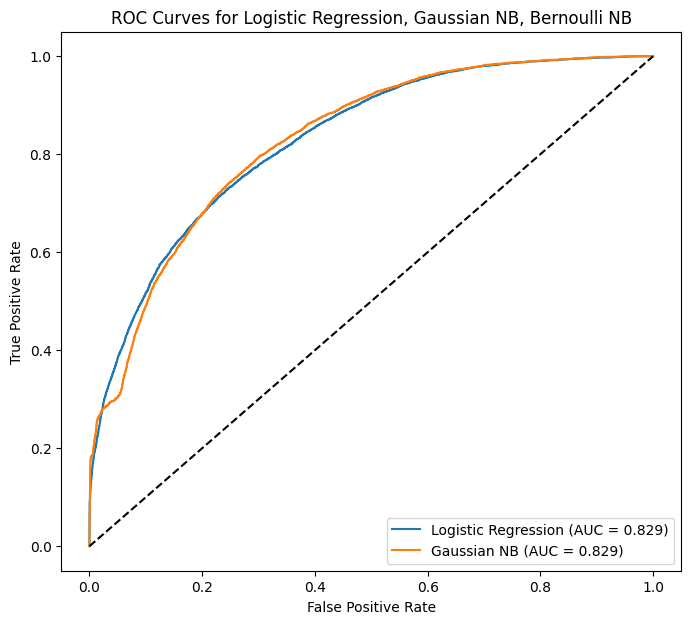

In [ ]:
# plot the carve
plt.figure(figsize=(8, 7))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {auc_log:.3f})")
plt.plot(fpr_gnb, tpr_gnb, label=f"Gaussian NB (AUC = {auc_gnb:.3f})")
#plt.plot(fpr_bnb, tpr_bnb, label=f"Bernoulli NB (AUC = {auc_bnb:.3f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Logistic Regression, Gaussian NB, Bernoulli NB")
plt.legend(loc="lower right")
plt.show()

In [ ]:
# # Making predictions on the test set

y_pred = b_model.predict(X_bcwd_test_scaled)

# ((predictions)) vs (actual values)
print("Predicted values:", y_pred)
print()
print("Actual values:", y_bcwd_test.values)

Predicted values: [0 1 1 0 0 1 1 1 1 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 1 1 0 0 0 1 1 0 0 1 1 0 1
 0 0 0 1 0 0 1 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 0 0 1 0 0 1
 0 0 1 0 1 0 0 0 1 1 0 0 1 0 1 1 0 0 1 1 1 0 0 0 1 0 0 1 1 0 1 0 0 1 0 1 1
 1 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0]

Actual values: [0 1 1 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0 1 1 0 0 0 1 1 0 0 1 1 0 1
 0 0 0 1 0 0 1 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 0 0 1 0 0 1
 0 0 1 0 1 0 0 0 1 0 0 0 1 0 1 1 0 0 1 1 1 0 0 0 1 0 0 0 1 0 1 0 0 1 0 1 1
 1 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0]


In [ ]:
# Compute metrics Bernoulli Naive Bayes on BCWD dataset
b_y_pred = b_model.predict(X_bcwd_test_scaled)

b_accuracy = accuracy_score(y_bcwd_test, b_y_pred) # accuracy

b_precision = precision_score(y_bcwd_test, b_y_pred) # precision

b_recall = recall_score(y_bcwd_test, b_y_pred) # recall

b_f1 = f1_score(y_bcwd_test, b_y_pred) # f1

b_roc_auc = roc_auc_score(y_bcwd_test, b_model.predict_proba(X_bcwd_test)[:, 1]) # ROC-AUC Score


print("\nBernoulli Naive Bayes Evaluation on BCWD Data:")
print(f"Accuracy: {b_accuracy:.4f}")
print(f"Precision: {b_precision:.4f}")
print(f"Recall: {b_recall:.4f}")
print(f"F1-Score: {b_f1:.4f}")
print(f"ROC-AUC Score: {b_roc_auc:.4f}")


Bernoulli Naive Bayes Evaluation on BCWD Data:
Accuracy: 0.9649
Precision: 0.9524
Recall: 0.9524
F1-Score: 0.9524
ROC-AUC Score: 0.5324


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but BernoulliNB was fitted without feature names
  warnings.warn(


/nconfusion matrices for Bernoulli


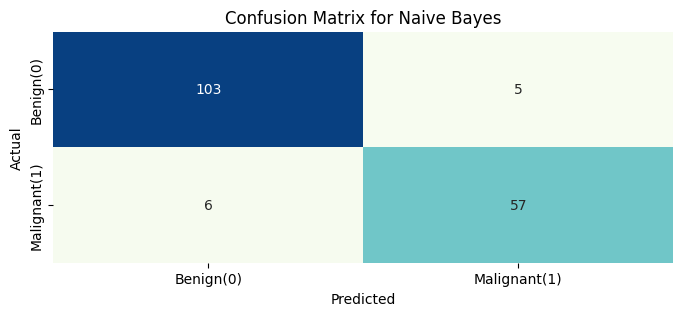

In [ ]:
# confusion matrices for Bernoulli
b_cm = confusion_matrix(y_bcwd_test, nb_y_pred)
print("/nconfusion matrices for Bernoulli")
plt.figure(figsize=(8, 3))
sns.heatmap(nb_cm, annot=True, fmt='d', cmap='GnBu', cbar=False, xticklabels=['Benign(0)', 'Malignant(1)'], yticklabels=['Benign(0)', 'Malignant(1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Naive Bayes')
plt.show()

***ROC curves***

In [ ]:
# Get the predicted probabilities for the positive class for each model
y_prob_LR = LR_model.predict_proba(X_bcwd_test_scaled)[:, 1]
y_prob_nb = nb_model.predict_proba(X_bcwd_test_scaled)[:, 1]
y_prob_b = b_model.predict_proba(X_bcwd_test_scaled)[:, 1]

# Calculate the False Positive Rate, True Positive Rate, and thresholds
fpr_log, tpr_log, _ = roc_curve(y_bcwd_test, y_prob_LR)
fpr_gnb, tpr_gnb, _ = roc_curve(y_bcwd_test, y_prob_nb)
fpr_bnb, tpr_bnb, _ = roc_curve(y_bcwd_test, y_prob_b)

# Calculate the Area Under the ROC Curve (AUC)
auc_log = roc_auc_score(y_bcwd_test, y_prob_LR)
auc_gnb = roc_auc_score(y_bcwd_test, y_prob_nb)
auc_bnb = roc_auc_score(y_bcwd_test, y_prob_b)


# **Comparative Analysis**
| Metric       | Logistic Regression | Gaussian Naive Bayes |  Birnoulli
|--------------|---------------------|----------------------|----------------
| Accuracy     | 0.81                | 0.8                  |0.80
| Precision    | 0.71                | 0.66                 |0.65
| Recall       | 0.37                | 0.3                  |0.36
| F1-Score     | 0.49                | 0.41                 |0.47
| ROC-AUC Score| 0.83                | 0.82                 |0.79

- Models performed lower than expectation which indicate that it's failed to identify the income '>$50K' (False Negative).
- Characteristics of dataset (feature types, distributions) influenced results because the dataset had both numbers and categories, Logistic Regression performed very well due to its suitability.